# **Исследование методов эффективного применения адаптеров (LoRA)  для дообучения моделей в условиях ограниченных вычислительных ресурсов**

**Содержание работы:**
1. EDA (самостоятельно собранные данные (fontanka.ru и dp.ru))
2. Эксперименты с моделью Qwen2.5-1.5B:
- Эксперимент 1 - Baseline
  - эксперимент проводится для датасета в объеме 8212 / 8000 / 3000 / 1500 / 300 образцов в каждом классе обучающей выборки
- Эксперимент 2 - LoRA
  - эксперимент проводится для датасета в объеме 8212 / 8000 / 3000 / 1500 / 300 образцов в каждом классе обучающей выборки
- Эксперимент 3 - QLoRA
  - эксперимент проводится для датасета в объеме 8212 / 8000 / 3000 / 1500 / 300 образцов в каждом классе обучающей выборки
- Эксперимент 4 - OrthoGeoLoRA
  - эксперимент проводится для датасета в объеме 8212 / 8000 / 3000 / 1500 / 300 образцов в каждом классе обучающей выборки

# Настройка окружения и инициализация

In [1]:
!pip install transformers accelerate peft datasets evaluate bitsandbytes


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [2]:
%pip -q install "transformers>=4.43" "datasets>=2.18" "accelerate>=0.33" "trl>=0.9" "bitsandbytes>=0.45"

import os, random, math, time
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from datasets import load_dataset
from transformers import (
    AutoTokenizer, AutoModelForCausalLM,
    DataCollatorForLanguageModeling
)

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(torch.cuda.is_available())

MODEL_NAME = "Qwen/Qwen2.5-1.5B"

DTYPE = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
print("device:", device, "| dtype:", DTYPE)


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
True
device: cuda | dtype: torch.bfloat16


In [3]:
import torch
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import Dataset
from sklearn.model_selection import train_test_split
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    BitsAndBytesConfig
)
from peft import LoraConfig, get_peft_model, TaskType
from sklearn.metrics import accuracy_score, f1_score
import evaluate

# **EDA (заголовки с fontanka.ru и dp.ru)**

- Загрузка датасета - самостоятельно собранные заголовки с сайтов fontanka.ru и dp.ru
- EDA (размеры, классы, длины, графики)

In [4]:
# Загрузка датасета
ds = pd.read_csv('result.csv')

In [5]:
ds

,text,label
0,Петербург и Ленобласть в этом году отремонтиру...,auto
1,Прямое железнодорожное сообщение свяжет Мурман...,auto
2,Поддать газу. Hyundai в следующем году начнет ...,auto
3,"Двое водителей не поделили проспект Науки, и о...",auto
4,Литий-ионные батареи для российских электромоб...,auto
...,...,...
41055,КХЛ отменила регулярный чемпионат,sport
41056,В Петербурге появился третий профессиональный ...,sport
41057,Российский гонщик отметил победу в Португалии ...,sport
41058,Защитник «Зенита» против лимита: меньше иностр...,sport


Список колонок:
['text', 'label']

Размер датасета:
(41060, 2)

Три случайных примера:

Пример 1639:
Text: За октябрь инспекторы ГАИ выявили в Петербурге и Ленобласти более 800 случаев вождения в нетрезвом состоянии, сообщили в пресс-службе региональной Госавтоинспекции.
Label: auto

Пример 18024:
Text: В январе-сентябре 2019 года операционная прибыль филиала Альфа-Банка в Петербурге составила 10,9 млрд рублей, что на 37% больше показателя за аналогичный период прошлого года. Об этом сообщает пресс-служба кредитной организации.
Label: finances

Пример 16049:
Text: В Кирове во время турнира умер молодой боец ММА
Label: sport

Train size: 32848
Test size:  8212

Columns: ['text', 'label']

Class distribution (train):
label
realty      8212
sport       8212
finances    8212
auto        8212
Name: count, dtype: int64

Class distribution (test):
label
realty      2053
auto        2053
finances    2053
sport       2053
Name: count, dtype: int64

Average text length (train): 107.4 characters


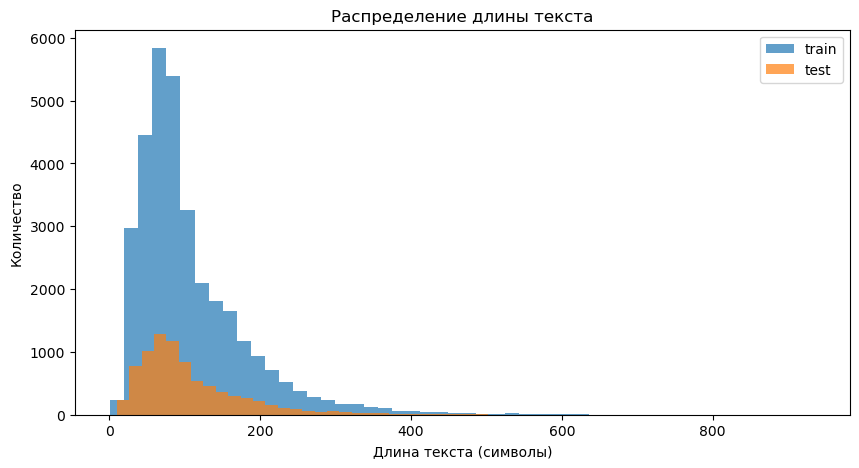

In [6]:
# Делим данные
X = ds['text']
y = ds['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Объединяем обратно в DataFrame
train = pd.DataFrame({
    'text': X_train,
    'label': y_train
}).reset_index(drop=True)

test = pd.DataFrame({
    'text': X_test,
    'label': y_test
}).reset_index(drop=True)

# Основная информация
print("Список колонок:")
print(ds.columns.tolist())

print("\nРазмер датасета:")
print(ds.shape)

# Случайные примеры
print("\nТри случайных примера:")

random_indices = random.sample(range(len(train)), 3)

for idx in random_indices:
    example = train.iloc[idx]
    print(f"\nПример {idx}:")
    print(f"Text: {example['text']}")
    print(f"Label: {example['label']}")

# Статистика
df_train = train.copy()
df_test = test.copy()

print(f"\nTrain size: {len(df_train)}")
print(f"Test size:  {len(df_test)}")

print("\nColumns:", df_train.columns.tolist())

# Распределение классов
print("\nClass distribution (train):")
print(df_train['label'].value_counts())

print("\nClass distribution (test):")
print(df_test['label'].value_counts())

# Длина текста
df_train['text_len'] = df_train['text'].apply(len)
df_test['text_len'] = df_test['text'].apply(len)

print(f"\nAverage text length (train): {df_train['text_len'].mean():.1f} characters")
print(f"Average text length (test):  {df_test['text_len'].mean():.1f} characters")

print(f"Text length range (train): {df_train['text_len'].min()} - {df_train['text_len'].max()}")
print(f"Text length range (test):  {df_test['text_len'].min()} - {df_test['text_len'].max()}")

plt.figure(figsize=(10,5))
plt.hist(df_train['text_len'], bins=50, alpha=0.7, label='train')
plt.hist(df_test['text_len'], bins=50, alpha=0.7, label='test')
plt.xlabel("Длина текста (символы)")
plt.ylabel("Количество")
plt.title("Распределение длины текста")
plt.legend()
plt.show()

In [7]:
# Преобразование label в числа
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
train['label'] = le.fit_transform(train['label'])
test['label'] = le.transform(test['label'])

num_labels = len(le.classes_)

In [8]:
# части датасета
# 8000 образцов в каждом классе обучающей выборки
train_8000 = (
    train.groupby('label', group_keys=False)
      .apply(lambda x: x.sample(n=8000, random_state=42))
      .reset_index(drop=True)
)

# Проверка
print(train_8000['label'].value_counts())
print("Размер:", train_8000.shape)


# 3000 образцов в каждом классе обучающей выборки
train_3000 = (
    train.groupby('label', group_keys=False)
      .apply(lambda x: x.sample(n=3000, random_state=42))
      .reset_index(drop=True)
)

# Проверка
print(train_3000['label'].value_counts())
print("Размер:", train_3000.shape)

# 1500 образцов в каждом классе обучающей выборки
train_1500 = (
    train.groupby('label', group_keys=False)
      .apply(lambda x: x.sample(n=1500, random_state=42))
      .reset_index(drop=True)
)

# Проверка
print(train_1500['label'].value_counts())
print("Размер:", train_1500.shape)

# 300 образцов в каждом классе обучающей выборки
train_300 = (
    train.groupby('label', group_keys=False)
      .apply(lambda x: x.sample(n=300, random_state=42))
      .reset_index(drop=True)
)

# Проверка
print(train_300['label'].value_counts())
print("Размер:", train_300.shape)

label
0    8000
1    8000
2    8000
3    8000
Name: count, dtype: int64
Размер: (32000, 2)
label
0    3000
1    3000
2    3000
3    3000
Name: count, dtype: int64
Размер: (12000, 2)
label
0    1500
1    1500
2    1500
3    1500
Name: count, dtype: int64
Размер: (6000, 2)
label
0    300
1    300
2    300
3    300
Name: count, dtype: int64
Размер: (1200, 2)


/tmp/ipykernel_5908/3427294923.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=8000, random_state=42))
/tmp/ipykernel_5908/3427294923.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=3000, random_state=42))
/tmp/ipykernel_5908/3427294923.py:28: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a f

# Подготовка токенизатора

In [9]:
#Подготовка токенизатора
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Добавляем pad_token
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

In [10]:
def prepare_dataset(train=train, test=test, sample_frac=1.0, seed=42):
    """
    Подготовка датасета:
    - pandas в HF Dataset
    - сэмплирование
    - токенизация
    - label в labels
    """

    # 1. pandas в Dataset
    train_ds = Dataset.from_pandas(train)
    test_ds = Dataset.from_pandas(test)

    # 2. Сэмплирование
    train_ds = train_ds.shuffle(seed=seed).select(
        range(int(sample_frac * len(train_ds)))
    )

    # 3. Токенизация
    train_tok = train_ds.map(tokenize, batched=True)
    test_tok = test_ds.map(tokenize, batched=True)

    # 4. Удаление лишнего
    train_tok = train_tok.remove_columns(["text"])
    test_tok = test_tok.remove_columns(["text"])

    # 5. label → labels
    train_tok = train_tok.rename_column("label", "labels")
    test_tok = test_tok.rename_column("label", "labels")

    # 6. Формат для PyTorch
    train_tok.set_format("torch")
    test_tok.set_format("torch")

    return train_tok, test_tok

# **Эксперимент 1 - Baseline**

**План эксперимента 1 - Baseline**:

- Определение функций для эксперимента
- Определение объема выборки
- Baseline-эксперимент:
  - загружается базовая модель Qwen2.5-1.5B
  - замораживаются все параметры, кроме классификационной головы
  - Trainer обучает 1 эпоху
  - собираются baseline-метрики

Для каждого запуска:
- обучение
- оценка
- замеры скорости
- замеры GPU-памяти

Агрегация результатов:
- DataFrame df_results
- добавление baseline
- сохранение в lora_results.csv
- вывод сводной таблицы

Повтор эксперимента для выборки на 8212 / 3000 / 1500 / 300 образцов в каждом классе обучающей выборки

### Функции для эксперимента 1

In [11]:
def load_base_model():
    return AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=num_labels,
        torch_dtype=torch.float16,
        device_map="auto",
        ignore_mismatched_sizes=True
    )

In [12]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1_score(labels, predictions, average="weighted")
    }

In [13]:
# Заморозка модели (baseline)
def freeze_all_but_head(model):
    for name, param in model.named_parameters():
        if "classifier" not in name and "score" not in name:
            param.requires_grad = False
    return model


# Подсчёт trainable параметров
def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# Обучение + инференс
def train_and_predict(model, train_tok, test_tok, tokenizer):
    args = TrainingArguments(
        output_dir="./outputs/baseline",
        num_train_epochs=1,
        per_device_train_batch_size=4,
        per_device_eval_batch_size=4,
        fp16=False,
        logging_steps=50,
        eval_strategy="epoch",
        save_strategy="no",
        report_to="none",
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_tok,
        eval_dataset=test_tok,
        processing_class=tokenizer,
        data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
        compute_metrics=compute_metrics,
    )

    start = time.time()
    trainer.train()
    mid = time.time()

    pred_test = trainer.predict(test_tok)
    end = time.time()

    pred_train = trainer.predict(train_tok)

    return pred_train, pred_test, mid - start, end - mid


# Подсчёт метрик
def compute_full_metrics(pred):
    logits = pred.predictions
    labels = pred.label_ids
    preds = np.argmax(logits, axis=-1)

    loss = F.cross_entropy(
        torch.tensor(logits),
        torch.tensor(labels)
    ).item()

    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="weighted"),
        "loss": loss
    }


# GPU метрики
def get_gpu_metrics():
    if torch.cuda.is_available():
        return {
            "gpu_memory_allocated_gb": torch.cuda.max_memory_allocated() / 1024**3,
            "gpu_memory_reserved_gb": torch.cuda.max_memory_reserved() / 1024**3,
        }
    return {
        "gpu_memory_allocated_gb": 0,
        "gpu_memory_reserved_gb": 0,
    }


# функция baseline
def run_baseline(train_tok, test_tok, tokenizer):
    print("\nЗапуск Baseline (только classification head)")

    model = load_base_model()
    model = freeze_all_but_head(model)

    print(f"Trainable parameters: {count_trainable_params(model):,}")

    pred_train, pred_test, time_train, time_eval = train_and_predict(
        model, train_tok, test_tok, tokenizer
    )

    train_metrics = compute_full_metrics(pred_train)
    test_metrics = compute_full_metrics(pred_test)
    gpu_metrics = get_gpu_metrics()

    return {
        "train_accuracy": train_metrics["accuracy"],
        "train_f1": train_metrics["f1"],
        "train_loss": train_metrics["loss"],
        "test_accuracy": test_metrics["accuracy"],
        "test_f1": test_metrics["f1"],
        "test_loss": test_metrics["loss"],
        "time_sec_train": time_train,
        "time_sec_eval": time_eval,
        **gpu_metrics
    }

### **8212 образцов в каждом классе обучающей выборки**

In [14]:
train_tok, test_tok = prepare_dataset(sample_frac=1.0)

Map:   0%|          | 0/32848 [00:00<?, ? examples/s]

Map:   0%|          | 0/8212 [00:00<?, ? examples/s]

In [15]:
baseline_metrics = run_baseline(train_tok, test_tok, tokenizer)
baseline_metrics

`torch_dtype` is deprecated! Use `dtype` instead!



Запуск Baseline (только classification head)


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Qwen2ForSequenceClassification LOAD REPORT from: Qwen/Qwen2.5-1.5B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 6,144


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.497701,0.435303,0.856308,0.855917


{'train_accuracy': 0.8438565513882124,
 'train_f1': 0.8437632154936954,
 'train_loss': 0.458251953125,
 'test_accuracy': 0.8563078421821725,
 'test_f1': 0.8559171131718452,
 'test_loss': 0.435302734375,
 'time_sec_train': 429.6961827278137,
 'time_sec_eval': 83.47486233711243,
 'gpu_memory_allocated_gb': 3.0882797241210938,
 'gpu_memory_reserved_gb': 3.11328125}

In [16]:
# Создаем DataFrame из baseline_metrics (одна строка)
df_baseline_metrics = pd.DataFrame([baseline_metrics])

# Сохраняем результаты
df_baseline_metrics.to_csv("qw2_DP_baseline_100pct.csv", index=False)
print("\nРезультаты сохранены в qw2_PD_baseline_100pct.csv")


Результаты сохранены в qw2_PD_baseline_100pct.csv


### **8000 образцов в каждом классе обучающей выборки**

In [17]:
train_tok, test_tok = prepare_dataset(train=train_8000)

Map:   0%|          | 0/32000 [00:00<?, ? examples/s]

Map:   0%|          | 0/8212 [00:00<?, ? examples/s]

In [18]:
baseline_metrics = run_baseline(train_tok, test_tok, tokenizer)
baseline_metrics


Запуск Baseline (только classification head)


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Qwen2ForSequenceClassification LOAD REPORT from: Qwen/Qwen2.5-1.5B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 6,144


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.573633,0.809082,0.789211,0.788795


{'train_accuracy': 0.78290625,
 'train_f1': 0.7830884571686418,
 'train_loss': 0.8427734375,
 'test_accuracy': 0.7892109108621529,
 'test_f1': 0.7887948391896289,
 'test_loss': 0.8095703125,
 'time_sec_train': 419.6878924369812,
 'time_sec_eval': 83.22118043899536,
 'gpu_memory_allocated_gb': 3.0882644653320312,
 'gpu_memory_reserved_gb': 3.11328125}

In [19]:
# Создаем DataFrame из baseline_metrics (одна строка)
df_baseline_metrics = pd.DataFrame([baseline_metrics])

# Сохраняем результаты
df_baseline_metrics.to_csv("qw2_DP_baseline_8000.csv", index=False)
print("\nРезультаты сохранены в qw2_PD_baseline_8000.csv")


Результаты сохранены в qw2_PD_baseline_8000.csv


### **3000 образцов в каждом классе обучающей выборки**

In [25]:
train_tok, test_tok = prepare_dataset(train=train_3000)

Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Map:   0%|          | 0/8212 [00:00<?, ? examples/s]

In [26]:
baseline_metrics = run_baseline(train_tok, test_tok, tokenizer)
baseline_metrics


Запуск Baseline (только classification head)


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Qwen2ForSequenceClassification LOAD REPORT from: Qwen/Qwen2.5-1.5B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 6,144


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,327.042500,304.750000,0.470044,0.472142


{'train_accuracy': 0.4815833333333333,
 'train_f1': 0.4829570376888769,
 'train_loss': inf,
 'test_accuracy': 0.47004383828543594,
 'test_f1': 0.4721421716191225,
 'test_loss': inf,
 'time_sec_train': 210.3860363960266,
 'time_sec_eval': 83.4746835231781,
 'gpu_memory_allocated_gb': 8.626214027404785,
 'gpu_memory_reserved_gb': 8.681640625}

In [27]:
# Создаем DataFrame из baseline_metrics (одна строка)
df_baseline_metrics = pd.DataFrame([baseline_metrics])

# Сохраняем результаты
df_baseline_metrics.to_csv("qw2_PD_baseline_3000pct.csv", index=False)
print("\nРезультаты сохранены в qw2_PD_baseline_3000pct.csv")


Результаты сохранены в qw2_PD_baseline_3000pct.csv


### **1500 образцов в каждом классе обучающей выборки**

In [28]:
train_tok, test_tok = prepare_dataset(train=train_1500)

Map:   0%|          | 0/6000 [00:00<?, ? examples/s]

Map:   0%|          | 0/8212 [00:00<?, ? examples/s]

In [29]:
baseline_metrics = run_baseline(train_tok, test_tok, tokenizer)
baseline_metrics


Запуск Baseline (только classification head)


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Qwen2ForSequenceClassification LOAD REPORT from: Qwen/Qwen2.5-1.5B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 6,144


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,607.520000,580.500000,0.476985,0.455729


{'train_accuracy': 0.48283333333333334,
 'train_f1': 0.4637148315414695,
 'train_loss': inf,
 'test_accuracy': 0.4769849001461276,
 'test_f1': 0.45572871162263207,
 'test_loss': inf,
 'time_sec_train': 147.32614636421204,
 'time_sec_eval': 83.80320835113525,
 'gpu_memory_allocated_gb': 8.626214027404785,
 'gpu_memory_reserved_gb': 8.681640625}

In [30]:
# Создаем DataFrame из baseline_metrics (одна строка)
df_baseline_metrics = pd.DataFrame([baseline_metrics])

# Сохраняем результаты
df_baseline_metrics.to_csv("qw2_PD_baseline_1500.csv", index=False)
print("\nРезультаты сохранены в qw2_PD_baseline_1500.csv")


Результаты сохранены в qw2_PD_baseline_1500.csv


### **300 образцов в каждом классе обучающей выборки**

In [31]:
train_tok, test_tok = prepare_dataset(train=train_300)

Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

Map:   0%|          | 0/8212 [00:00<?, ? examples/s]

In [32]:
# Baseline: только classification head
print("\nЗапуск Baseline (только classification head)")
base_model = load_base_model()
# Замораживаем все слои кроме классификационной головы
for name, param in base_model.named_parameters():
    if "classifier" not in name and "score" not in name:
        param.requires_grad = False

print(f"Trainable parameters in baseline: {sum(p.numel() for p in base_model.parameters() if p.requires_grad):,}")


Запуск Baseline (только classification head)


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Qwen2ForSequenceClassification LOAD REPORT from: Qwen/Qwen2.5-1.5B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable parameters in baseline: 6,144


In [33]:
baseline_metrics = run_baseline(train_tok, test_tok, tokenizer)
baseline_metrics


Запуск Baseline (только classification head)


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Qwen2ForSequenceClassification LOAD REPORT from: Qwen/Qwen2.5-1.5B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 6,144


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.295991,1.216797,0.522041,0.512269


{'train_accuracy': 0.5291666666666667,
 'train_f1': 0.5221422606626875,
 'train_loss': 1.1669921875,
 'test_accuracy': 0.5220409157330735,
 'test_f1': 0.5122688182074567,
 'test_loss': 1.2177734375,
 'time_sec_train': 96.7963342666626,
 'time_sec_eval': 83.99800419807434,
 'gpu_memory_allocated_gb': 8.839791774749756,
 'gpu_memory_reserved_gb': 8.91015625}

In [34]:
# Создаем DataFrame из baseline_metrics (одна строка)
df_baseline_metrics = pd.DataFrame([baseline_metrics])

# Сохраняем результаты
df_baseline_metrics.to_csv("qw2_PD_baseline_300.csv", index=False)
print("\nРезультаты сохранены в qw2_PD_baseline_300.csv")


Результаты сохранены в qw2_PD_baseline_300.csv


# **Эксперимент 2 - LoRA**

**План эксперимента 2 - LoRA**:

- Определение функций для эксперимента
- Определение объема выборки
- LoRA эксперименты
  - Rank
    - 4
    - 8
    - 16
    - 32
  - Наборы модулей
    - ["q_proj", "v_proj"]
    - ["q_proj", "k_proj", "v_proj"]
    - ["q_proj", "k_proj", "v_proj", "o_proj"]

Для каждого запуска:
- обучение
- оценка
- замеры скорости
- замеры GPU-памяти

Агрегация результатов:
- DataFrame df_results
- сохранение в lora_results.csv
- вывод сводной таблицы


Повтор эксперимента для выборки на 8212 / 3000 / 1500 / 300 образцов в каждом классе обучающей выборки

### Функции для эксперимента 2

In [14]:
def create_lora_model(rank, target_modules):
    base = load_base_model()

    lora_cfg = LoraConfig(
        r=rank,
        lora_alpha=rank * 2,
        lora_dropout=0.05,
        target_modules=target_modules,
        task_type=TaskType.SEQ_CLS
    )
    return get_peft_model(base, lora_cfg)

def create_training_args(rank, target_modules, output_dir="./outputs"):
    name = f"r{rank}_" + "-".join(target_modules)

    return TrainingArguments(
        output_dir=f"{output_dir}/{name}",
        num_train_epochs=1,
        per_device_train_batch_size=4,
        per_device_eval_batch_size=4,
        fp16=False,
        logging_steps=50,
        eval_strategy="epoch",
        save_strategy="no",
        report_to="none",
        remove_unused_columns=False,
        dataloader_num_workers=4,
        logging_dir=f"{output_dir}/{name}/logs",
    )

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1_score(labels, predictions, average="weighted")
    }

def run_experiment(rank, target_modules, output_dir="./outputs"):

    metrics = {}

    # Создаем модель
    model = create_lora_model(rank, target_modules)
    print(f"Trainable parameters: {model.num_parameters(only_trainable=True):,}")

    # Создаем аргументы для тренировки
    args = create_training_args(rank, target_modules, output_dir)

    # Data collator
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    # Trainer
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_tok,
        eval_dataset=test_tok,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    # Мониторинг GPU до тренировки
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

    start_time = time.time()

    # Тренировка
    trainer.train()

    end_time_train = time.time()

    print("Getting predictions on test set...")
    pred_test = trainer.predict(test_tok)

    end_time_eval = time.time()

    print("Getting predictions on train set...")
    pred_train = trainer.predict(train_tok)

    # Оценка
    logits_train = pred_train.predictions
    labels_train = pred_train.label_ids
    preds_train = np.argmax(logits_train, axis=-1)
    logits_tensor_train = torch.tensor(logits_train)
    labels_tensor_train = torch.tensor(labels_train)
    loss_train = F.cross_entropy(logits_tensor_train, labels_tensor_train).item()

    logits_test = pred_test.predictions
    labels_test = pred_test.label_ids
    preds_test = np.argmax(logits_test, axis=-1)
    logits_tensor_test = torch.tensor(logits_test)
    labels_tensor_test = torch.tensor(labels_test)
    loss_test = F.cross_entropy(logits_tensor_test, labels_tensor_test).item()

    # Сбор метрик GPU
    if torch.cuda.is_available():
        gpu_memory_allocated = torch.cuda.max_memory_allocated() / 1024**3  # в GB
        gpu_memory_reserved = torch.cuda.max_memory_reserved() / 1024**3    # в GB
    else:
        gpu_memory_allocated = 0
        gpu_memory_reserved = 0

    # Добавляем все метрики в результат
    metrics["time_sec_train"] = end_time_train - start_time
    metrics["time_sec_eval"] = end_time_eval - end_time_train
    metrics["rank"] = rank
    metrics["modules"] = "-".join(target_modules)
    metrics["gpu_memory_allocated_gb"] = gpu_memory_allocated
    metrics["gpu_memory_reserved_gb"] = gpu_memory_reserved
    metrics["trainable_parameters"] = model.num_parameters(only_trainable=True)

    metrics["train_accuracy"] = accuracy_score(labels_train, preds_train)
    metrics["train_f1"] = f1_score(labels_train, preds_train, average="weighted")
    metrics["train_loss"] = loss_train

    metrics["test_accuracy"] = accuracy_score(labels_test, preds_test)
    metrics["test_f1"] = f1_score(labels_test, preds_test, average="weighted")
    metrics["test_loss"] = loss_test

    # Очистка памяти
    del model
    del trainer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return metrics

### **8212 образцов в каждом классе обучающей выборки**

In [20]:
train_tok, test_tok = prepare_dataset(sample_frac=1.0)

Map:   0%|          | 0/32848 [00:00<?, ? examples/s]

Map:   0%|          | 0/8212 [00:00<?, ? examples/s]

In [21]:
# LoRA эксперименты
ranks = [4, 8, 16, 32]
modules_list = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]

results = []

for r in ranks:
    for m in modules_list:
        print(f"\n=== Запуск LoRA r={r}, modules={m} ===")
        try:
            metrics = run_experiment(rank=r, target_modules=m)
            print(metrics)
            results.append(metrics)
        except Exception as e:
            print(f"Ошибка в эксперименте r={r}, modules={m}: {e}")
            continue


=== Запуск LoRA r=4, modules=['q_proj', 'v_proj'] ===


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Qwen2ForSequenceClassification LOAD REPORT from: Qwen/Qwen2.5-1.5B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 550,912


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.173156,0.346680,0.924744,0.924577


...

Trainable parameters: 8,722,432


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.188476,0.322754,0.931320,0.931250


Getting predictions on test set...


Getting predictions on train set...


{'time_sec_train': 1238.7116024494171, 'time_sec_eval': 111.39848351478577, 'rank': 32, 'modules': 'q_proj-k_proj-v_proj-o_proj', 'gpu_memory_allocated_gb': 9.034577369689941, 'gpu_memory_reserved_gb': 9.130859375, 'trainable_parameters': 8722432, 'train_accuracy': 0.9395701412566975, 'train_f1': 0.9395507676183512, 'train_loss': 0.270263671875, 'test_accuracy': 0.9313200194836824, 'test_f1': 0.9312498024475576, 'test_loss': 0.32275390625}


**Агрегация результатов**

In [22]:
# Создаем DataFrame со всеми результатами
df_results = pd.DataFrame(results)

# Сохраняем результаты
df_results.to_csv("qw2_PD_lora_results_8212.csv", index=False)
print("\nРезультаты сохранены в qw2_PD_lora_results_8212.csv")
df_results


Результаты сохранены в qw2_PD_lora_results_8212.csv


,time_sec_train,time_sec_eval,rank,modules,gpu_memory_allocated_gb,gpu_memory_reserved_gb,trainable_parameters,train_accuracy,train_f1,train_loss,test_accuracy,test_f1,test_loss
0,1013.484837,93.433874,4,q_proj-v_proj,8.526344,8.615234,550912,0.925840,0.925782,0.335693,0.924744,0.924577,0.346680
1,1087.137623,97.669183,4,q_proj-k_proj-v_proj,8.733085,8.812500,751616,0.914089,0.914144,inf,0.907574,0.907478,inf
2,1187.477843,103.532436,4,q_proj-k_proj-v_proj-o_proj,8.947196,9.021484,1095680,0.932386,0.932329,0.311768,0.927789,0.927615,0.325195
3,1014.711863,93.688215,8,q_proj-v_proj,8.529228,8.621094,1095680,0.917621,0.917738,inf,0.913663,0.913666,2.919922
4,1087.641733,97.746118,8,q_proj-k_proj-v_proj,8.737144,8.822266,1497088,0.918473,0.918498,inf,0.910010,0.909908,5.597656
5,1190.812888,103.280695,8,q_proj-k_proj-v_proj-o_proj,8.952964,9.035156,2185216,0.934608,0.934531,0.296631,0.929250,0.929086,0.319092
6,1006.020431,93.582958,16,q_proj-v_proj,8.534996,8.636719,2185216,0.922339,0.922332,inf,0.915246,0.915178,2.642578
7,1080.128349,97.640640,16,q_proj-k_proj-v_proj,8.747075,8.843750,2988032,0.917255,0.917319,inf,0.908670,0.908516,4.234375
8,1185.868560,103.756568,16,q_proj-k_proj-v_proj-o_proj,8.979035,9.064453,4364288,0.938505,0.938422,0.280273,0.932051,0.931889,0.319580
9,1040.763654,97.410668,32,q_proj-v_proj,8.554666,8.662109,4364288,0.925475,0.925421,inf,0.919021,0.918902,3.029297


### **8000 образцов в каждом классе обучающей выборки**

In [21]:
train_tok, test_tok = prepare_dataset(train=train_8000)

Map:   0%|          | 0/32000 [00:00<?, ? examples/s]

Map:   0%|          | 0/8212 [00:00<?, ? examples/s]

In [22]:
# LoRA эксперименты
ranks = [4, 8, 16, 32]
modules_list = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]

results = []

for r in ranks:
    for m in modules_list:
        print(f"\n=== Запуск LoRA r={r}, modules={m} ===")
        try:
            metrics = run_experiment(rank=r, target_modules=m)
            print(metrics)
            results.append(metrics)
        except Exception as e:
            print(f"Ошибка в эксперименте r={r}, modules={m}: {e}")
            continue


=== Запуск LoRA r=4, modules=['q_proj', 'v_proj'] ===


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Qwen2ForSequenceClassification LOAD REPORT from: Qwen/Qwen2.5-1.5B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 550,912


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,2.755737,2.892578,0.909157,0.909167


...

Trainable parameters: 8,722,432


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.222279,0.310547,0.930833,0.930767


Getting predictions on test set...


Getting predictions on train set...


{'time_sec_train': 1208.2341735363007, 'time_sec_eval': 111.45298314094543, 'rank': 32, 'modules': 'q_proj-k_proj-v_proj-o_proj', 'gpu_memory_allocated_gb': 6.158684253692627, 'gpu_memory_reserved_gb': 6.24609375, 'trainable_parameters': 8722432, 'train_accuracy': 0.94440625, 'train_f1': 0.9444015762324018, 'train_loss': 0.2373046875, 'test_accuracy': 0.930832927423283, 'test_f1': 0.9307671135837835, 'test_loss': 0.310546875}


**Агрегация результатов**

In [23]:
# Создаем DataFrame со всеми результатами
df_results = pd.DataFrame(results)

# Сохраняем результаты
df_results.to_csv("qw2_PD_lora_results_8000.csv", index=False)
print("\nРезультаты сохранены в qw2_PD_lora_results_8000.csv")
df_results


Результаты сохранены в qw2_PD_lora_results_8000.csv


,time_sec_train,time_sec_eval,rank,modules,gpu_memory_allocated_gb,gpu_memory_reserved_gb,trainable_parameters,train_accuracy,train_f1,train_loss,test_accuracy,test_f1,test_loss
0,988.906322,93.477663,4,q_proj-v_proj,5.651793,5.738281,550912,0.912781,0.912895,inf,0.909157,0.909167,2.894531
1,1063.418060,97.522535,4,q_proj-k_proj-v_proj,5.857680,5.929688,751616,0.924438,0.924481,0.340088,0.926327,0.926255,0.349365
2,1158.950155,103.427238,4,q_proj-k_proj-v_proj-o_proj,6.070815,6.136719,1095680,0.918906,0.918893,1.419922,0.916585,0.916507,1.641602
3,991.715883,93.434412,8,q_proj-v_proj,5.655288,5.746094,1095680,0.912219,0.912087,inf,0.907453,0.907220,4.105469
4,1066.071574,97.648592,8,q_proj-k_proj-v_proj,5.861739,5.941406,1497088,0.930312,0.930386,0.304688,0.927180,0.927182,0.324219
5,1162.640146,103.200107,8,q_proj-k_proj-v_proj-o_proj,6.076583,6.150391,2185216,0.934312,0.934378,0.288574,0.930224,0.930200,0.310791
6,985.071782,93.396245,16,q_proj-v_proj,5.661056,5.759766,2185216,0.914406,0.914098,inf,0.910132,0.909719,3.257812
7,1057.535312,97.592557,16,q_proj-k_proj-v_proj,5.872159,5.960938,2988032,0.935906,0.935993,0.281982,0.929128,0.929103,0.315918
8,1151.351848,103.808916,16,q_proj-k_proj-v_proj-o_proj,6.103142,6.177734,4364288,0.939906,0.939926,0.260986,0.933755,0.933699,0.302246
9,1015.851245,97.352737,32,q_proj-v_proj,5.679749,5.787109,4364288,0.919406,0.919292,2.015625,0.912567,0.912358,2.503906


### **3000 образцов в каждом классе обучающей выборки**

In [36]:
train_tok, test_tok = prepare_dataset(train=train_3000)

Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Map:   0%|          | 0/8212 [00:00<?, ? examples/s]

In [37]:
# LoRA эксперименты
ranks = [4, 8, 16, 32]
modules_list = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]

results = []

for r in ranks:
    for m in modules_list:
        print(f"\n=== Запуск LoRA r={r}, modules={m} ===")
        try:
            metrics = run_experiment(rank=r, target_modules=m)
            print(metrics)
            results.append(metrics)
        except Exception as e:
            print(f"Ошибка в эксперименте r={r}, modules={m}: {e}")
            continue


=== Запуск LoRA r=4, modules=['q_proj', 'v_proj'] ===


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Qwen2ForSequenceClassification LOAD REPORT from: Qwen/Qwen2.5-1.5B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 550,912


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,2.065683,2.474609,0.824403,0.824144


...

Trainable parameters: 8,722,432


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.372558,0.350342,0.926571,0.926512


Getting predictions on test set...


Getting predictions on train set...


{'time_sec_train': 527.1139662265778, 'time_sec_eval': 110.83583617210388, 'rank': 32, 'modules': 'q_proj-k_proj-v_proj-o_proj', 'gpu_memory_allocated_gb': 11.912545204162598, 'gpu_memory_reserved_gb': 12.00390625, 'trainable_parameters': 8722432, 'train_accuracy': 0.9409166666666666, 'train_f1': 0.941026393268409, 'train_loss': 0.26904296875, 'test_accuracy': 0.9265708718947882, 'test_f1': 0.9265115362589835, 'test_loss': 0.3505859375}


**Агрегация результатов**

In [38]:
# Создаем DataFrame со всеми результатами
df_results = pd.DataFrame(results)

# Сохраняем результаты
df_results.to_csv("qw2_PD_lora_results_3000.csv", index=False)
print("\nРезультаты сохранены в qw2_PD_lora_results_3000.csv")
df_results


Результаты сохранены в qw2_PD_lora_results_3000.csv


,time_sec_train,time_sec_eval,rank,modules,gpu_memory_allocated_gb,gpu_memory_reserved_gb,trainable_parameters,train_accuracy,train_f1,train_loss,test_accuracy,test_f1,test_loss
0,430.215250,93.610481,4,q_proj-v_proj,11.404190,11.515625,550912,0.830167,0.829798,2.220703,0.824403,0.824144,2.476562
1,459.274256,97.095612,4,q_proj-k_proj-v_proj,11.611541,11.695312,751616,0.919667,0.919666,0.365234,0.914150,0.913969,0.382812
2,496.576054,102.851737,4,q_proj-k_proj-v_proj-o_proj,11.825164,11.900391,1095680,0.923250,0.923344,0.354980,0.921335,0.921280,0.376709
3,427.480779,93.000046,8,q_proj-v_proj,11.407196,11.501953,1095680,0.921083,0.921074,0.362549,0.915855,0.915774,0.385986
4,457.182746,96.819669,8,q_proj-k_proj-v_proj,11.615600,11.695312,1497088,0.923667,0.923632,0.347412,0.918777,0.918607,0.374512
5,495.563448,102.583665,8,q_proj-k_proj-v_proj-o_proj,11.830932,11.908203,2185216,0.931500,0.931580,0.324707,0.922552,0.922446,0.363770
6,428.849332,93.958778,16,q_proj-v_proj,11.412963,11.509766,2185216,0.928333,0.928404,0.321533,0.921456,0.921494,0.356934
7,458.852280,98.053751,16,q_proj-k_proj-v_proj,11.625043,11.712891,2988032,0.931750,0.931752,0.327393,0.921091,0.920952,0.377197
8,498.425922,104.239791,16,q_proj-k_proj-v_proj-o_proj,11.857003,11.941406,4364288,0.936583,0.936665,0.290283,0.928154,0.928112,0.354004
9,444.130153,97.818445,32,q_proj-v_proj,11.431657,11.539062,4364288,0.935500,0.935599,0.297363,0.925597,0.925561,0.351562


### **1500 образцов в каждом классе обучающей выборки**

In [18]:
train_tok, test_tok = prepare_dataset(train=train_1500)

Map:   0%|          | 0/6000 [00:00<?, ? examples/s]

Map:   0%|          | 0/8212 [00:00<?, ? examples/s]

In [19]:
# LoRA эксперименты
ranks = [4, 8, 16, 32]
modules_list = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]

results = []

for r in ranks:
    for m in modules_list:
        print(f"\n=== Запуск LoRA r={r}, modules={m} ===")
        try:
            metrics = run_experiment(rank=r, target_modules=m)
            print(metrics)
            results.append(metrics)
        except Exception as e:
            print(f"Ошибка в эксперименте r={r}, modules={m}: {e}")
            continue


=== Запуск LoRA r=4, modules=['q_proj', 'v_proj'] ===


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Qwen2ForSequenceClassification LOAD REPORT from: Qwen/Qwen2.5-1.5B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 550,912


...

Trainable parameters: 8,722,432


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,12.577229,10.507812,0.895153,0.895139


Getting predictions on test set...


Getting predictions on train set...


{'time_sec_train': 317.6563301086426, 'time_sec_eval': 111.35111737251282, 'rank': 32, 'modules': 'q_proj-k_proj-v_proj-o_proj', 'gpu_memory_allocated_gb': 6.158684253692627, 'gpu_memory_reserved_gb': 6.24609375, 'trainable_parameters': 8722432, 'train_accuracy': 0.92, 'train_f1': 0.9200628922007924, 'train_loss': 7.2421875, 'test_accuracy': 0.8951534339990258, 'test_f1': 0.8951387254540395, 'test_loss': inf}


**Агрегация результатов**

In [20]:
# Создаем DataFrame со всеми результатами
df_results = pd.DataFrame(results)

# Сохраняем результаты
df_results.to_csv("qw2_PD_lora_results_1500.csv", index=False)
print("\nРезультаты сохранены в qw2_PD_lora_results_1500.csv")
df_results


Результаты сохранены в qw2_PD_lora_results_1500.csv


,time_sec_train,time_sec_eval,rank,modules,gpu_memory_allocated_gb,gpu_memory_reserved_gb,trainable_parameters,train_accuracy,train_f1,train_loss,test_accuracy,test_f1,test_loss
0,261.206582,93.102907,4,q_proj-v_proj,5.652404,5.738281,550912,0.911333,0.911329,inf,0.886020,0.885873,inf
1,277.082092,97.226454,4,q_proj-k_proj-v_proj,5.857680,5.929688,751616,0.914667,0.914491,inf,0.889308,0.888995,inf
2,299.549806,102.550389,4,q_proj-k_proj-v_proj-o_proj,6.070815,6.136719,1095680,0.915500,0.915376,inf,0.901242,0.901088,inf
3,260.396994,92.905624,8,q_proj-v_proj,5.655288,5.746094,1095680,0.914333,0.914369,0.357422,0.905504,0.905311,0.405518
4,276.562428,96.720968,8,q_proj-k_proj-v_proj,5.861739,5.941406,1497088,0.907833,0.908007,9.742188,0.887969,0.887949,inf
5,299.477981,102.385130,8,q_proj-k_proj-v_proj-o_proj,6.076583,6.150391,2185216,0.914667,0.914469,inf,0.899415,0.898988,inf
6,261.490422,93.432980,16,q_proj-v_proj,5.661056,5.759766,2185216,0.924167,0.924188,0.322266,0.911349,0.911190,0.385254
7,277.219589,97.701774,16,q_proj-k_proj-v_proj,5.872159,5.960938,2988032,0.918000,0.917956,9.148438,0.894545,0.894327,inf
8,300.790846,103.693270,16,q_proj-k_proj-v_proj-o_proj,6.103142,6.177734,4364288,0.909500,0.909249,8.968750,0.893936,0.893520,inf
9,270.412980,97.132442,32,q_proj-v_proj,5.679749,5.787109,4364288,0.927000,0.926986,0.352783,0.910862,0.910658,0.438965


### **300 образцов в каждом классе обучающей выборки**

In [21]:
train_tok, test_tok = prepare_dataset(train=train_300)

Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

Map:   0%|          | 0/8212 [00:00<?, ? examples/s]

In [22]:
# LoRA эксперименты
ranks = [4, 8, 16, 32]
modules_list = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]

results = []

for r in ranks:
    for m in modules_list:
        print(f"\n=== Запуск LoRA r={r}, modules={m} ===")
        try:
            metrics = run_experiment(rank=r, target_modules=m)
            print(metrics)
            results.append(metrics)
        except Exception as e:
            print(f"Ошибка в эксперименте r={r}, modules={m}: {e}")
            continue


=== Запуск LoRA r=4, modules=['q_proj', 'v_proj'] ===


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Qwen2ForSequenceClassification LOAD REPORT from: Qwen/Qwen2.5-1.5B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 550,912


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.084048,1.061523,0.563444,0.557246


...

Trainable parameters: 8,722,432


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,19.282588,13.070312,0.795543,0.795937


Getting predictions on test set...


Getting predictions on train set...


{'time_sec_train': 153.70861792564392, 'time_sec_eval': 111.72513914108276, 'rank': 32, 'modules': 'q_proj-k_proj-v_proj-o_proj', 'gpu_memory_allocated_gb': 6.158684253692627, 'gpu_memory_reserved_gb': 6.24609375, 'trainable_parameters': 8722432, 'train_accuracy': 0.8525, 'train_f1': 0.8529531815524071, 'train_loss': 7.53515625, 'test_accuracy': 0.7955431076473454, 'test_f1': 0.7959366689203466, 'test_loss': inf}


**Агрегация результатов**

In [23]:
# Создаем DataFrame со всеми результатами
df_results = pd.DataFrame(results)

# Сохраняем результаты
df_results.to_csv("lora_PD_results_300.csv", index=False)
print("\nРезультаты сохранены в lora_PD_results_300.csv")
df_results


Результаты сохранены в lora_PD_results_300.csv


,time_sec_train,time_sec_eval,rank,modules,gpu_memory_allocated_gb,gpu_memory_reserved_gb,trainable_parameters,train_accuracy,train_f1,train_loss,test_accuracy,test_f1,test_loss
0,127.600184,93.295839,4,q_proj-v_proj,5.652404,5.738281,550912,0.596667,0.590063,1.010742,0.563444,0.557246,1.061523
1,133.913086,97.067670,4,q_proj-k_proj-v_proj,5.857680,5.929688,751616,0.599167,0.589560,1.013672,0.581101,0.571211,1.032227
2,142.793298,102.777970,4,q_proj-k_proj-v_proj-o_proj,6.070815,6.136719,1095680,0.813333,0.814009,28.265625,0.754993,0.754803,inf
3,127.251798,93.069426,8,q_proj-v_proj,5.655288,5.746094,1095680,0.839167,0.838708,31.625000,0.797857,0.797738,inf
4,133.958793,97.031480,8,q_proj-k_proj-v_proj,5.861739,5.941406,1497088,0.610000,0.599347,0.963379,0.595348,0.584691,0.999023
5,142.899339,102.704367,8,q_proj-k_proj-v_proj-o_proj,6.076583,6.150391,2185216,0.586667,0.586423,1.820312,0.570019,0.569479,1.940430
6,127.821786,93.600332,16,q_proj-v_proj,5.661056,5.759766,2185216,0.848333,0.848094,44.093750,0.816001,0.815625,inf
7,134.505266,97.699728,16,q_proj-k_proj-v_proj,5.872159,5.960938,2988032,0.681667,0.671983,0.807617,0.647954,0.637254,0.876953
8,144.164752,104.029334,16,q_proj-k_proj-v_proj-o_proj,6.103142,6.177734,4364288,0.642500,0.638536,1.089844,0.588773,0.583896,1.285156
9,132.672162,97.415223,32,q_proj-v_proj,5.679749,5.787109,4364288,0.795833,0.796111,7.171875,0.765222,0.766753,inf


# Эксперимент 3 - QLoRA

**План эксперимента 3 - QLoRA**:

- Определение функций для эксперимента
- Определение объема выборки
- LoRA эксперименты
  - Rank
    - 4
    - 8
    - 16
    - 32
  - Наборы модулей
    - ["q_proj", "v_proj"]
    - ["q_proj", "k_proj", "v_proj"]
    - ["q_proj", "k_proj", "v_proj", "o_proj"]
  - Методы квантизации
    - NF4
    - FP4

Для каждого запуска:
- обучение
- оценка
- замеры скорости
- замеры GPU-памяти

Агрегация результатов:
- DataFrame df_results
- сохранение в qlora_results.csv
- вывод сводной таблицы

Повтор эксперимента для выборки на 8212 / 3000 / 1500 / 300 образцов в каждом классе обучающей выборки

### Функции для эксперимента 3

In [15]:
# Функция создания модели с QLoRA

def create_qlora_model(rank, target_modules, quant_type="nf4"):
    """
    Создает модель с 4-битным квантованием и LoRA адаптерами

    Args:
        rank: ранг LoRA
        target_modules: список модулей для адаптации
        quant_type: тип квантования ("nf4" или "fp4")
    """

    # Конфигурация квантования
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type=quant_type,  # "nf4" или "fp4"
        bnb_4bit_compute_dtype=torch.bfloat16,
        bnb_4bit_use_double_quant=True,
    )

    # Загружаем базовую модель с квантованием
    base_model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=num_labels,
        quantization_config=bnb_config,
        device_map="auto",
        torch_dtype=torch.bfloat16,
        trust_remote_code=True
    )

    # Конфигурация LoRA
    lora_config = LoraConfig(
        r=rank,
        lora_alpha=rank * 2,
        target_modules=target_modules,
        lora_dropout=0.05,
        bias="none",
        task_type=TaskType.SEQ_CLS
    )

    # Оборачиваем модель в LoRA
    model = get_peft_model(base_model, lora_config)

    return model

In [16]:
# Функция для вычисления метрик

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1_score(labels, predictions, average="weighted")
    }

In [17]:
# Функция для запуска эксперимента

def run_experiment(rank, target_modules, quant_type="nf4", output_dir="./qlora_outputs"):
    """
    Запускает один эксперимент QLoRA

    Args:
        rank: ранг LoRA
        target_modules: список модулей
        quant_type: тип квантования ("nf4" или "fp4")
        output_dir: директория для сохранения

    Returns:
        dict: метрики эксперимента
    """

    # Создаем уникальное имя для эксперимента
    modules_str = "-".join(target_modules)
    exp_name = f"qlora_{quant_type}_r{rank}_{modules_str}"

    print(f"\n{'='*60}")
    print(f"Запуск: {exp_name}")
    print(f"{'='*60}")

    metrics = {}

    # Создаем модель
    try:
        model = create_qlora_model(rank, target_modules, quant_type)
        trainable_params = model.num_parameters(only_trainable=True)
        print(f"Trainable parameters: {trainable_params:,}")
    except Exception as e:
        print(f"Ошибка при создании модели: {e}")
        return None

    # Аргументы для тренировки
    training_args = TrainingArguments(
        output_dir=f"{output_dir}/{exp_name}",
        num_train_epochs=1,
        per_device_train_batch_size=4,
        per_device_eval_batch_size=4,
        logging_steps=50,
        eval_strategy="epoch",
        save_strategy="no",
        fp16=False,
        bf16=True,
        report_to="none",
        remove_unused_columns=False,
        dataloader_num_workers=4,
        logging_dir=f"{output_dir}/{exp_name}/logs"
    )

    # Data collator
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    # Trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_tok,
        eval_dataset=test_tok,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    # Мониторинг GPU до тренировки
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

    start_time = time.time()

    # Тренировка
    trainer.train()

    end_time_train = time.time()

    print("Getting predictions on test set...")
    pred_test = trainer.predict(test_tok)

    end_time_eval = time.time()

    print("Getting predictions on train set...")
    pred_train = trainer.predict(train_tok)

    # Оценка
    logits_train = pred_train.predictions
    labels_train = pred_train.label_ids
    preds_train = np.argmax(logits_train, axis=-1)
    logits_tensor_train = torch.tensor(logits_train)
    labels_tensor_train = torch.tensor(labels_train)
    loss_train = F.cross_entropy(logits_tensor_train, labels_tensor_train).item()

    logits_test = pred_test.predictions
    labels_test = pred_test.label_ids
    preds_test = np.argmax(logits_test, axis=-1)
    logits_tensor_test = torch.tensor(logits_test)
    labels_tensor_test = torch.tensor(labels_test)
    loss_test = F.cross_entropy(logits_tensor_test, labels_tensor_test).item()

    # Сбор метрик GPU
    if torch.cuda.is_available():
        gpu_memory_allocated = torch.cuda.max_memory_allocated() / 1024**3  # в GB
        gpu_memory_reserved = torch.cuda.max_memory_reserved() / 1024**3    # в GB
    else:
        gpu_memory_allocated = 0
        gpu_memory_reserved = 0

    # Добавляем все метрики в результат
    metrics["time_sec_train"] = end_time_train - start_time
    metrics["time_sec_eval"] = end_time_eval - end_time_train
    metrics["rank"] = rank
    metrics["modules"] = "-".join(target_modules)
    metrics["gpu_memory_allocated_gb"] = gpu_memory_allocated
    metrics["gpu_memory_reserved_gb"] = gpu_memory_reserved
    metrics["trainable_parameters"] = model.num_parameters(only_trainable=True)

    metrics["train_accuracy"] = accuracy_score(labels_train, preds_train)
    metrics["train_f1"] = f1_score(labels_train, preds_train, average="weighted")
    metrics["train_loss"] = loss_train

    metrics["test_accuracy"] = accuracy_score(labels_test, preds_test)
    metrics["test_f1"] = f1_score(labels_test, preds_test, average="weighted")
    metrics["test_loss"] = loss_test

    # Очистка памяти
    del model
    del trainer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return metrics

### **8212 образцов в каждом классе обучающей выборки**

In [17]:
train_tok, test_tok = prepare_dataset(sample_frac=1.0)

Map:   0%|          | 0/32848 [00:00<?, ? examples/s]

Map:   0%|          | 0/8212 [00:00<?, ? examples/s]

In [18]:
# Параметры экспериментов
ranks = [4, 8, 16, 32]
target_modules_sets = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]
quant_types = ["nf4"]  # Тестируем оба типа квантования ["nf4", "fp4"]

# Список для сбора результатов
qlora_results = []

# Запускаем все комбинации
for quant_type in quant_types:
    for modules in target_modules_sets:
        for rank in ranks:
            print(f"\n>>> Тестируем: {quant_type}, rank={rank}, modules={modules}")

            metrics = run_experiment(
                rank=rank,
                target_modules=modules,
                quant_type=quant_type
            )
            print(metrics)

            if metrics:
                qlora_results.append(metrics)

            # Небольшая пауза между экспериментами
            time.sleep(2)


>>> Тестируем: nf4, rank=4, modules=['q_proj', 'v_proj']

Запуск: qlora_nf4_r4_q_proj-v_proj


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Qwen2ForSequenceClassification LOAD REPORT from: Qwen/Qwen2.5-1.5B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 550,912


...

Trainable parameters: 8,722,432


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.214599,0.312295,0.931929,0.931779


Getting predictions on test set...


Getting predictions on train set...


{'time_sec_train': 1799.7599067687988, 'time_sec_eval': 173.90706872940063, 'rank': 32, 'modules': 'q_proj-k_proj-v_proj-o_proj', 'gpu_memory_allocated_gb': 4.043708801269531, 'gpu_memory_reserved_gb': 4.1875, 'trainable_parameters': 8722432, 'train_accuracy': 0.9445323916220165, 'train_f1': 0.9445230838832571, 'train_loss': 0.2421044111251831, 'test_accuracy': 0.9319288845591817, 'test_f1': 0.9317791762130115, 'test_loss': 0.31223875284194946}


In [19]:
# Создаем DataFrame
df_qlora_results_100pct = pd.DataFrame(qlora_results)

# Сохраняем результаты
df_qlora_results_100pct.to_csv("qw2_PD_qlora_results_8212_nf4.csv", index=False)
print("\nРезультаты сохранены в qw2_PD_qlora_results_8212_nf4.csv")


Результаты сохранены в qw2_PD_qlora_results_8212_nf4.csv


In [20]:
# Параметры экспериментов
ranks = [4, 8, 16, 32]
target_modules_sets = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]
quant_types = ["fp4"]  # Тестируем оба типа квантования ["nf4", "fp4"]

# Список для сбора результатов
qlora_results = []

# Запускаем все комбинации
for quant_type in quant_types:
    for modules in target_modules_sets:
        for rank in ranks:
            print(f"\n>>> Тестируем: {quant_type}, rank={rank}, modules={modules}")

            metrics = run_experiment(
                rank=rank,
                target_modules=modules,
                quant_type=quant_type
            )
            print(metrics)

            if metrics:
                qlora_results.append(metrics)

            # Небольшая пауза между экспериментами
            time.sleep(2)


>>> Тестируем: fp4, rank=4, modules=['q_proj', 'v_proj']

Запуск: qlora_fp4_r4_q_proj-v_proj


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Qwen2ForSequenceClassification LOAD REPORT from: Qwen/Qwen2.5-1.5B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 550,912


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.206358,0.384858,0.918047,0.917923


...

Trainable parameters: 8,722,432


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.155326,0.316341,0.933390,0.933277


Getting predictions on test set...


Getting predictions on train set...


{'time_sec_train': 1825.163003206253, 'time_sec_eval': 177.6792871952057, 'rank': 32, 'modules': 'q_proj-k_proj-v_proj-o_proj', 'gpu_memory_allocated_gb': 4.041999816894531, 'gpu_memory_reserved_gb': 4.234375, 'trainable_parameters': 8722432, 'train_accuracy': 0.9447759376522162, 'train_f1': 0.9447423089142937, 'train_loss': 0.23644226789474487, 'test_accuracy': 0.93339016074038, 'test_f1': 0.933276748166972, 'test_loss': 0.3162648677825928}


In [21]:
# Создаем DataFrame
df_qlora_results_100pct = pd.DataFrame(qlora_results)

# Сохраняем результаты
df_qlora_results_100pct.to_csv("qw2_PD_qlora_results_8212_fp4.csv", index=False)
print("\nРезультаты сохранены в qw2_PD_qlora_results_8212_fp4.csv")


Результаты сохранены в qw2_PD_qlora_results_8212_fp4.csv


### **8000 образцов в каждом классе обучающей выборки**

In [18]:
train_tok, test_tok = prepare_dataset(train=train_8000)

Map:   0%|          | 0/32000 [00:00<?, ? examples/s]

Map:   0%|          | 0/8212 [00:00<?, ? examples/s]

In [19]:
# Параметры экспериментов
ranks = [4, 8, 16, 32]
target_modules_sets = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]
quant_types = ["nf4", "fp4"]  # Тестируем оба типа квантования ["nf4", "fp4"]

# Список для сбора результатов
qlora_results = []

# Запускаем все комбинации
for quant_type in quant_types:
    for modules in target_modules_sets:
        for rank in ranks:
            print(f"\n>>> Тестируем: {quant_type}, rank={rank}, modules={modules}")

            metrics = run_experiment(
                rank=rank,
                target_modules=modules,
                quant_type=quant_type
            )
            print(metrics)

            if metrics:
                qlora_results.append(metrics)

            # Небольшая пауза между экспериментами
            time.sleep(2)


>>> Тестируем: nf4, rank=4, modules=['q_proj', 'v_proj']

Запуск: qlora_nf4_r4_q_proj-v_proj


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Qwen2ForSequenceClassification LOAD REPORT from: Qwen/Qwen2.5-1.5B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 550,912


...

Trainable parameters: 8,722,432


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.333504,0.316506,0.930346,0.930388


Getting predictions on test set...


Getting predictions on train set...


{'time_sec_train': 1798.5355892181396, 'time_sec_eval': 178.86640810966492, 'rank': 32, 'modules': 'q_proj-k_proj-v_proj-o_proj', 'gpu_memory_allocated_gb': 4.041816711425781, 'gpu_memory_reserved_gb': 4.306640625, 'trainable_parameters': 8722432, 'train_accuracy': 0.94265625, 'train_f1': 0.9427290460046281, 'train_loss': 0.24393442273139954, 'test_accuracy': 0.9303458353628836, 'test_f1': 0.9303879152734809, 'test_loss': 0.3164706230163574}


In [20]:
# Создаем DataFrame
df_qlora_results_50pct = pd.DataFrame(qlora_results)

# Сохраняем результаты
df_qlora_results_50pct.to_csv("qw2_PD_qlora_results_8000.csv", index=False)
print("\nРезультаты сохранены в qw2_PD_qlora_results_8000.csv")


Результаты сохранены в qw2_PD_qlora_results_8000.csv


### **3000 образцов в каждом классе обучающей выборки**

In [48]:
train_tok, test_tok = prepare_dataset(train=train_3000)

Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Map:   0%|          | 0/8212 [00:00<?, ? examples/s]

In [49]:
# Параметры экспериментов
ranks = [4, 8, 16, 32]
target_modules_sets = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]
quant_types = ["nf4", "fp4"]  # Тестируем оба типа квантования ["nf4", "fp4"]

# Список для сбора результатов
qlora_results = []

# Запускаем все комбинации
for quant_type in quant_types:
    for modules in target_modules_sets:
        for rank in ranks:
            print(f"\n>>> Тестируем: {quant_type}, rank={rank}, modules={modules}")

            metrics = run_experiment(
                rank=rank,
                target_modules=modules,
                quant_type=quant_type
            )
            print(metrics)

            if metrics:
                qlora_results.append(metrics)

            # Небольшая пауза между экспериментами
            time.sleep(2)


>>> Тестируем: nf4, rank=4, modules=['q_proj', 'v_proj']

Запуск: qlora_nf4_r4_q_proj-v_proj


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Qwen2ForSequenceClassification LOAD REPORT from: Qwen/Qwen2.5-1.5B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 550,912


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.527118,0.391690,0.907696,0.907716


...

Trainable parameters: 8,722,432


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.400928,0.343238,0.924014,0.924093


Getting predictions on test set...


Getting predictions on train set...


{'time_sec_train': 792.5449059009552, 'time_sec_eval': 182.24478268623352, 'rank': 32, 'modules': 'q_proj-k_proj-v_proj-o_proj', 'gpu_memory_allocated_gb': 9.776634693145752, 'gpu_memory_reserved_gb': 9.990234375, 'trainable_parameters': 8722432, 'train_accuracy': 0.9415833333333333, 'train_f1': 0.9417089250458078, 'train_loss': 0.26301196217536926, 'test_accuracy': 0.9240136385776911, 'test_f1': 0.9240928865131531, 'test_loss': 0.3432076573371887}


In [50]:
# Создаем DataFrame
df_qlora_results_50pct = pd.DataFrame(qlora_results)

# Сохраняем результаты
df_qlora_results_50pct.to_csv("qw2_PD_qlora_results_3000.csv", index=False)
print("\nРезультаты сохранены в qw2_PD_qlora_results_3000.csv")


Результаты сохранены в qw2_PD_qlora_results_3000.csv


### **1500 образцов в каждом классе обучающей выборки**

In [51]:
train_tok, test_tok = prepare_dataset(train=train_1500)

Map:   0%|          | 0/6000 [00:00<?, ? examples/s]

Map:   0%|          | 0/8212 [00:00<?, ? examples/s]

In [52]:
# Параметры экспериментов
ranks = [4, 8, 16, 32]
target_modules_sets = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]
quant_types = ["nf4", "fp4"]  # Тестируем оба типа квантования ["nf4", "fp4"]

# Список для сбора результатов
qlora_results = []

# Запускаем все комбинации
for quant_type in quant_types:
    for modules in target_modules_sets:
        for rank in ranks:
            print(f"\n>>> Тестируем: {quant_type}, rank={rank}, modules={modules}")

            metrics = run_experiment(
                rank=rank,
                target_modules=modules,
                quant_type=quant_type
            )
            print(metrics)

            if metrics:
                qlora_results.append(metrics)

            # Небольшая пауза между экспериментами
            time.sleep(2)


>>> Тестируем: nf4, rank=4, modules=['q_proj', 'v_proj']

Запуск: qlora_nf4_r4_q_proj-v_proj


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Qwen2ForSequenceClassification LOAD REPORT from: Qwen/Qwen2.5-1.5B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 550,912


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.437846,0.402635,0.860326,0.860444


...

Trainable parameters: 8,722,432


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.551778,0.407228,0.914150,0.914009


Getting predictions on test set...


Getting predictions on train set...


{'time_sec_train': 483.7231423854828, 'time_sec_eval': 180.50179171562195, 'rank': 32, 'modules': 'q_proj-k_proj-v_proj-o_proj', 'gpu_memory_allocated_gb': 9.793968677520752, 'gpu_memory_reserved_gb': 10.1015625, 'trainable_parameters': 8722432, 'train_accuracy': 0.9358333333333333, 'train_f1': 0.9357522067691663, 'train_loss': 0.2881971001625061, 'test_accuracy': 0.914150024354603, 'test_f1': 0.9140089751918908, 'test_loss': 0.40715229511260986}


In [53]:
# Создаем DataFrame
df_qlora_results_10pct = pd.DataFrame(qlora_results)

# Сохраняем результаты
df_qlora_results_10pct.to_csv("qw2_PD_qlora_results_1500.csv", index=False)
print("\nРезультаты сохранены в qw2_PD_qlora_results_1500.csv")


Результаты сохранены в qw2_PD_qlora_results_1500.csv


### **300 образцов в каждом классе обучающей выборки**

In [17]:
train_tok, test_tok = prepare_dataset(train=train_300)

Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

Map:   0%|          | 0/8212 [00:00<?, ? examples/s]

In [55]:
# Параметры экспериментов
ranks = [4, 8, 16, 32]
target_modules_sets = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]
quant_types = ["nf4", "fp4"]  # Тестируем оба типа квантования ["nf4", "fp4"]

# Список для сбора результатов
qlora_results = []

# Запускаем все комбинации
for quant_type in quant_types:
    for modules in target_modules_sets:
        for rank in ranks:
            print(f"\n>>> Тестируем: {quant_type}, rank={rank}, modules={modules}")

            metrics = run_experiment(
                rank=rank,
                target_modules=modules,
                quant_type=quant_type
            )
            print(metrics)

            if metrics:
                qlora_results.append(metrics)

            # Небольшая пауза между экспериментами
            time.sleep(2)


>>> Тестируем: nf4, rank=4, modules=['q_proj', 'v_proj']

Запуск: qlora_nf4_r4_q_proj-v_proj


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Qwen2ForSequenceClassification LOAD REPORT from: Qwen/Qwen2.5-1.5B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 550,912


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.360757,1.369313,0.415002,0.409422


...

Trainable parameters: 8,722,432


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.646461,0.547253,0.796517,0.794528


Getting predictions on test set...


Getting predictions on train set...


{'time_sec_train': 244.04854774475098, 'time_sec_eval': 180.93992018699646, 'rank': 32, 'modules': 'q_proj-k_proj-v_proj-o_proj', 'gpu_memory_allocated_gb': 9.802513599395752, 'gpu_memory_reserved_gb': 10.197265625, 'trainable_parameters': 8722432, 'train_accuracy': 0.8366666666666667, 'train_f1': 0.8354283589974051, 'train_loss': 0.4333854615688324, 'test_accuracy': 0.7965172917681442, 'test_f1': 0.7945283402377217, 'test_loss': 0.5472221374511719}


In [56]:
# Создаем DataFrame
df_qlora_results_5pct = pd.DataFrame(qlora_results)

# Сохраняем результаты
df_qlora_results_5pct.to_csv("qw2_PD_qlora_results_300.csv", index=False)
print("\nРезультаты сохранены в qw2_PD_qlora_results_300.csv")


Результаты сохранены в qw2_PD_qlora_results_300.csv


In [ ]:
# Параметры экспериментов
ranks = [4, 8, 16, 32]
target_modules_sets = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]
quant_types = ["nf4", "fp4"]  # Тестируем оба типа квантования ["nf4", "fp4"]

# Список для сбора результатов
qlora_results = []

# Запускаем все комбинации
for quant_type in quant_types:
    for modules in target_modules_sets:
        for rank in ranks:
            print(f"\n>>> Тестируем: {quant_type}, rank={rank}, modules={modules}")

            metrics = run_experiment(
                rank=rank,
                target_modules=modules,
                quant_type=quant_type
            )
            print(metrics)

            if metrics:
                qlora_results.append(metrics)

            # Небольшая пауза между экспериментами
            time.sleep(2)


>>> Тестируем: nf4, rank=4, modules=['q_proj', 'v_proj']

Запуск: qlora_nf4_r4_q_proj-v_proj


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Qwen2ForSequenceClassification LOAD REPORT from: Qwen/Qwen2.5-1.5B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 550,912


...

Qwen2ForSequenceClassification LOAD REPORT from: Qwen/Qwen2.5-1.5B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 8,722,432


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.646461,0.547253,0.796517,0.794528


Getting predictions on test set...


Getting predictions on train set...


In [ ]:
# Создаем DataFrame
df_qlora_results_5pct = pd.DataFrame(qlora_results)

# Сохраняем результаты
df_qlora_results_5pct.to_csv("qw2_PD_qlora_results_300_v2.csv", index=False)
print("\nРезультаты сохранены в qw2_PD_qlora_results_300_v2.csv")

# Эксперимент 4 - OrthoGeoLoRA

**План эксперимента 4 - OrthoGeoLoRA**:

- Определение функций для эксперимента
- Определение объема выборки
- LoRA эксперименты
  - Rank
    - 4
    - 8
    - 16
    - 32
  - Наборы модулей
    - ["q_proj", "v_proj"]
    - ["q_proj", "k_proj", "v_proj"]
    - ["q_proj", "k_proj", "v_proj", "o_proj"]

Для каждого запуска:
- обучение
- оценка
- замеры скорости
- замеры GPU-памяти

Агрегация результатов:
- DataFrame df_results
- сохранение в oglora_results.csv
- вывод сводной таблицы

Повтор эксперимента для выборки 8212 / 3000 / 1500 / 300 %

### Функции для эксперимента 4

In [14]:
class OrthogonalizationLayer(nn.Module):
    def __init__(self, in_dim, rank, dtype):
        super().__init__()
        self.theta = nn.Parameter(torch.randn(in_dim, rank, dtype=torch.float32) * 0.01)

    def forward(self):
        q, r = torch.linalg.qr(self.theta, mode="reduced")
        sign = torch.sign(torch.diag(r))
        q = q * sign.unsqueeze(0)
        return q

In [15]:
class OrthoGeoLoRALayer(nn.Module):
    def __init__(self, base_lora_layer):
        super().__init__()

        self.base_layer = base_lora_layer.base_layer

        if isinstance(base_lora_layer.r, dict):
            self.rank = list(base_lora_layer.r.values())[0]
        else:
            self.rank = base_lora_layer.r

        if isinstance(base_lora_layer.scaling, dict):
            self.scaling = list(base_lora_layer.scaling.values())[0]
        else:
            self.scaling = base_lora_layer.scaling

        in_features = self.base_layer.in_features
        out_features = self.base_layer.out_features

        dtype = self.base_layer.weight.dtype

        self.A_orth = OrthogonalizationLayer(in_features, self.rank, dtype)
        self.B_orth = OrthogonalizationLayer(out_features, self.rank, dtype)

        self.log_singular = nn.Parameter(torch.zeros(self.rank, dtype=dtype))

    @property
    def singular(self):
        return F.softplus(self.log_singular) + 1e-6

    def forward(self, x):

        base = self.base_layer(x)

        A = self.A_orth().to(x.dtype)
        B = self.B_orth().to(x.dtype)
        S = self.singular.to(x.dtype)

        xA = torch.matmul(x, A)
        xS = xA * S.unsqueeze(0)
        update = torch.matmul(xS, B.T)

        return base + update * self.scaling

In [16]:
def convert_lora_to_orthogeolora(model):

    for name, module in list(model.named_modules()):

        if hasattr(module, "lora_A") and hasattr(module, "lora_B"):

            parent = model
            path = name.split(".")
            for p in path[:-1]:
                parent = getattr(parent, p)

            lora_layer = getattr(parent, path[-1])

            ortho_layer = OrthoGeoLoRALayer(lora_layer)

            setattr(parent, path[-1], ortho_layer)

    return model

In [17]:
def create_orthogeolora_model(rank, target_modules):

    base = load_base_model()

    lora_cfg = LoraConfig(
        r=rank,
        lora_alpha=rank * 2,
        lora_dropout=0.05,
        target_modules=target_modules,
        task_type=TaskType.SEQ_CLS
    )

    model = get_peft_model(base, lora_cfg)

    model = convert_lora_to_orthogeolora(model)

    return model

In [18]:
def create_lora_model(rank, target_modules):
    base = load_base_model()

    lora_cfg = LoraConfig(
        r=rank,
        lora_alpha=rank * 2,
        lora_dropout=0.05,
        target_modules=target_modules,
        task_type=TaskType.SEQ_CLS
    )
    return get_peft_model(base, lora_cfg)

def create_training_args(rank, target_modules, output_dir="./outputs"):
    name = f"r{rank}_" + "-".join(target_modules)

    return TrainingArguments(
        output_dir=f"{output_dir}/{name}",
        num_train_epochs=1,
        per_device_train_batch_size=4,
        per_device_eval_batch_size=4,
        fp16=False,
        logging_steps=50,
        eval_strategy="epoch",
        save_strategy="no",
        report_to="none",
        remove_unused_columns=False,
        dataloader_num_workers=4,
        logging_dir=f"{output_dir}/{name}/logs",
    )

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1_score(labels, predictions, average="weighted")
    }

def run_experiment_oglora(rank, target_modules, output_dir="./outputs"):

    metrics = {}

    # Создаем модель
    model = None
    trainer = None

    model = create_orthogeolora_model(rank, target_modules)
    print(f"Trainable parameters: {model.num_parameters(only_trainable=True):,}")

    # Создаем аргументы для тренировки
    args = create_training_args(rank, target_modules, output_dir)

    # Data collator
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    # Trainer
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_tok,
        eval_dataset=test_tok,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    # Мониторинг GPU до тренировки
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

    start_time = time.time()

    # Тренировка
    trainer.train()

    end_time_train = time.time()

    print("Getting predictions on train set...")
    pred_train = trainer.predict(train_tok)

    print("Getting predictions on test set...")
    pred_test = trainer.predict(test_tok)

    end_time_eval = time.time()

    # Оценка
    logits_train = pred_train.predictions
    labels_train = pred_train.label_ids
    preds_train = np.argmax(logits_train, axis=-1)
    logits_tensor_train = torch.tensor(logits_train)
    labels_tensor_train = torch.tensor(labels_train)
    loss_train = F.cross_entropy(logits_tensor_train, labels_tensor_train).item()

    logits_test = pred_test.predictions
    labels_test = pred_test.label_ids
    preds_test = np.argmax(logits_test, axis=-1)
    logits_tensor_test = torch.tensor(logits_test)
    labels_tensor_test = torch.tensor(labels_test)
    loss_test = F.cross_entropy(logits_tensor_test, labels_tensor_test).item()

    # Сбор метрик GPU
    if torch.cuda.is_available():
        gpu_memory_allocated = torch.cuda.max_memory_allocated() / 1024**3  # в GB
        gpu_memory_reserved = torch.cuda.max_memory_reserved() / 1024**3    # в GB
    else:
        gpu_memory_allocated = 0
        gpu_memory_reserved = 0

    # Добавляем все метрики в результат
    metrics["time_sec_train"] = end_time_train - start_time
    metrics["time_sec_eval"] = end_time_eval - end_time_train
    metrics["rank"] = rank
    metrics["modules"] = "-".join(target_modules)
    metrics["gpu_memory_allocated_gb"] = gpu_memory_allocated
    metrics["gpu_memory_reserved_gb"] = gpu_memory_reserved
    metrics["trainable_parameters"] = model.num_parameters(only_trainable=True)

    metrics["train_accuracy"] = accuracy_score(labels_train, preds_train)
    metrics["train_f1"] = f1_score(labels_train, preds_train, average="weighted")
    metrics["train_loss"] = loss_train

    metrics["test_accuracy"] = accuracy_score(labels_test, preds_test)
    metrics["test_f1"] = f1_score(labels_test, preds_test, average="weighted")
    metrics["test_loss"] = loss_test

    # Очистка памяти
    del model
    del trainer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return metrics

### **8212 образцов в каждом классе обучающей выборки**

In [29]:
train_tok, test_tok = prepare_dataset(sample_frac=1.0)

Map:   0%|          | 0/32848 [00:00<?, ? examples/s]

Map:   0%|          | 0/8212 [00:00<?, ? examples/s]

In [30]:
# LoRA эксперименты
ranks = [4, 8, 16, 32]
modules_list = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]

oglora_results = []

for r in ranks:
    for m in modules_list:
        print(f"\n=== Запуск OGLoRA r={r}, modules={m} ===")
        try:
          metrics = run_experiment_oglora(rank=r, target_modules=m)

          print(metrics)

          oglora_results.append(metrics)

        except Exception as e:
            print(f"Ошибка в эксперименте r={r}, modules={m}: {e}")
            continue


=== Запуск OGLoRA r=4, modules=['q_proj', 'v_proj'] ===


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Qwen2ForSequenceClassification LOAD REPORT from: Qwen/Qwen2.5-1.5B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 551,136


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.569832,0.905762,0.909766,0.909842


...

Trainable parameters: 8,726,016


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.518782,0.716309,0.913298,0.913280


Getting predictions on train set...


Getting predictions on test set...


{'time_sec_train': 3042.708158493042, 'time_sec_eval': 2262.314984560013, 'rank': 32, 'modules': 'q_proj-k_proj-v_proj-o_proj', 'gpu_memory_allocated_gb': 5.490082263946533, 'gpu_memory_reserved_gb': 5.552734375, 'trainable_parameters': 8726016, 'train_accuracy': 0.9231003409644423, 'train_f1': 0.9231981912530267, 'train_loss': 0.60107421875, 'test_accuracy': 0.913297613248904, 'test_f1': 0.9132798926397983, 'test_loss': 0.71630859375}


In [31]:
# Создаем DataFrame
df_oglora_results_100pct = pd.DataFrame(oglora_results)

# Сохраняем результаты
df_oglora_results_100pct.to_csv("qw2_oglora_PD_results_8212.csv", index=False)
print("\nРезультаты сохранены в qw2_oglora_PD_results_8212.csv")


Результаты сохранены в qw2_oglora_PD_results_8212.csv


### **8000 образцов в каждом классе обучающей выборки**

In [19]:
train_tok, test_tok = prepare_dataset(train=train_8000)

Map:   0%|          | 0/32000 [00:00<?, ? examples/s]

Map:   0%|          | 0/8212 [00:00<?, ? examples/s]

In [20]:
# LoRA эксперименты
ranks = [4, 8, 16, 32]
modules_list = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]

oglora_results = []

for r in ranks:
    for m in modules_list:
        print(f"\n=== Запуск OGLoRA r={r}, modules={m} ===")
        try:
          metrics = run_experiment_oglora(rank=r, target_modules=m)

          print(metrics)

          oglora_results.append(metrics)

        except Exception as e:
            print(f"Ошибка в эксперименте r={r}, modules={m}: {e}")
            continue


=== Запуск OGLoRA r=4, modules=['q_proj', 'v_proj'] ===


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Qwen2ForSequenceClassification LOAD REPORT from: Qwen/Qwen2.5-1.5B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 551,136


...

Trainable parameters: 8,726,016


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.669047,0.683594,0.913298,0.913253


Getting predictions on train set...


Getting predictions on test set...


{'time_sec_train': 2965.462182044983, 'time_sec_eval': 2206.520567417145, 'rank': 32, 'modules': 'q_proj-k_proj-v_proj-o_proj', 'gpu_memory_allocated_gb': 5.490082263946533, 'gpu_memory_reserved_gb': 5.552734375, 'trainable_parameters': 8726016, 'train_accuracy': 0.91996875, 'train_f1': 0.9199812480847966, 'train_loss': 0.57080078125, 'test_accuracy': 0.913297613248904, 'test_f1': 0.9132529772046365, 'test_loss': 0.68359375}


In [21]:
# Создаем DataFrame
df_oglora_results_50pct = pd.DataFrame(oglora_results)

# Сохраняем результаты
df_oglora_results_50pct.to_csv("qw2_PD_oglora_results_8000.csv", index=False)
print("\nРезультаты сохранены в qw2_PD_oglora_results_8000.csv")


Результаты сохранены в qw2_PD_oglora_results_8000.csv


### **3000 образцов в каждом классе обучающей выборки**

In [32]:
train_tok, test_tok = prepare_dataset(train=train_3000)

Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Map:   0%|          | 0/8212 [00:00<?, ? examples/s]

In [33]:
# LoRA эксперименты
ranks = [4, 8, 16, 32]
modules_list = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]

oglora_results = []

for r in ranks:
    for m in modules_list:
        print(f"\n=== Запуск OGLoRA r={r}, modules={m} ===")
        try:
          metrics = run_experiment_oglora(rank=r, target_modules=m)

          print(metrics)

          oglora_results.append(metrics)

        except Exception as e:
            print(f"Ошибка в эксперименте r={r}, modules={m}: {e}")
            continue


=== Запуск OGLoRA r=4, modules=['q_proj', 'v_proj'] ===


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Qwen2ForSequenceClassification LOAD REPORT from: Qwen/Qwen2.5-1.5B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 551,136


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.579243,0.412598,0.919264,0.919323


...

Qwen2ForSequenceClassification LOAD REPORT from: Qwen/Qwen2.5-1.5B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Trainable parameters: 5,972,608
Ошибка в эксперименте r=32, modules=['q_proj', 'k_proj', 'v_proj']: HIP error: an illegal memory access was encountered
Search for `hipErrorIllegalAddress' in https://rocm.docs.amd.com/projects/HIP/en/latest/index.html for more information.
HIP kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing AMD_SERIALIZE_KERNEL=3
Compile with `TORCH_USE_HIP_DSA` to enable device-side assertions.


=== Запуск OGLoRA r=32, modules=['q_proj', 'k_proj', 'v_proj', 'o_proj'] ===


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Qwen2ForSequenceClassification LOAD REPORT from: Qwen/Qwen2.5-1.5B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Trainable parameters: 8,726,016
Ошибка в эксперименте r=32, modules=['q_proj', 'k_proj', 'v_proj', 'o_proj']: HIP error: an illegal memory access was encountered
Search for `hipErrorIllegalAddress' in https://rocm.docs.amd.com/projects/HIP/en/latest/index.html for more information.
HIP kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing AMD_SERIALIZE_KERNEL=3
Compile with `TORCH_USE_HIP_DSA` to enable device-side assertions.



In [34]:
# Создаем DataFrame
df_oglora_results_50pct = pd.DataFrame(oglora_results)

# Сохраняем результаты
df_oglora_results_50pct.to_csv("qw2_PD_oglora_results_3000.csv", index=False)
print("\nРезультаты сохранены в qw2_PD_oglora_results_3000.csv")


Результаты сохранены в qw2_PD_oglora_results_3000.csv


### **1500 образцов в каждом классе обучающей выборки**

In [35]:
train_tok, test_tok = prepare_dataset(train=train_1500)

Map:   0%|          | 0/6000 [00:00<?, ? examples/s]

Map:   0%|          | 0/8212 [00:00<?, ? examples/s]

In [36]:
# LoRA эксперименты
ranks = [4, 8, 16, 32]
modules_list = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]

oglora_results = []

for r in ranks:
    for m in modules_list:
        print(f"\n=== Запуск OGLoRA r={r}, modules={m} ===")
        try:
          metrics = run_experiment_oglora(rank=r, target_modules=m)

          print(metrics)

          oglora_results.append(metrics)

        except Exception as e:
            print(f"Ошибка в эксперименте r={r}, modules={m}: {e}")
            continue


=== Запуск OGLoRA r=4, modules=['q_proj', 'v_proj'] ===


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Qwen2ForSequenceClassification LOAD REPORT from: Qwen/Qwen2.5-1.5B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Trainable parameters: 551,136
Ошибка в эксперименте r=4, modules=['q_proj', 'v_proj']: HIP error: an illegal memory access was encountered
Search for `hipErrorIllegalAddress' in https://rocm.docs.amd.com/projects/HIP/en/latest/index.html for more information.
HIP kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing AMD_SERIALIZE_KERNEL=3
Compile with `TORCH_USE_HIP_DSA` to enable device-side assertions.


=== Запуск OGLoRA r=4, modules=['q_proj', 'k_proj', 'v_proj'] ===


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

...

Qwen2ForSequenceClassification LOAD REPORT from: Qwen/Qwen2.5-1.5B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Trainable parameters: 5,972,608
Ошибка в эксперименте r=32, modules=['q_proj', 'k_proj', 'v_proj']: HIP error: an illegal memory access was encountered
Search for `hipErrorIllegalAddress' in https://rocm.docs.amd.com/projects/HIP/en/latest/index.html for more information.
HIP kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing AMD_SERIALIZE_KERNEL=3
Compile with `TORCH_USE_HIP_DSA` to enable device-side assertions.


=== Запуск OGLoRA r=32, modules=['q_proj', 'k_proj', 'v_proj', 'o_proj'] ===


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Qwen2ForSequenceClassification LOAD REPORT from: Qwen/Qwen2.5-1.5B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Trainable parameters: 8,726,016
Ошибка в эксперименте r=32, modules=['q_proj', 'k_proj', 'v_proj', 'o_proj']: HIP error: an illegal memory access was encountered
Search for `hipErrorIllegalAddress' in https://rocm.docs.amd.com/projects/HIP/en/latest/index.html for more information.
HIP kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing AMD_SERIALIZE_KERNEL=3
Compile with `TORCH_USE_HIP_DSA` to enable device-side assertions.



In [37]:
# Создаем DataFrame
df_oglora_results_10pct = pd.DataFrame(oglora_results)

# Сохраняем результаты
df_oglora_results_10pct.to_csv("qw2_PD_oglora_results_1500.csv", index=False)
print("\nРезультаты сохранены в qw2_PD_oglora_results_1500.csv")
df_oglora_results_10pct


Результаты сохранены в qw2_PD_oglora_results_1500.csv


""


### **300 образцов в каждом классе обучающей выборки**

In [38]:
train_tok, test_tok = prepare_dataset(train=train_300)

Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

Map:   0%|          | 0/8212 [00:00<?, ? examples/s]

In [39]:
# OGLoRA эксперименты
ranks = [4, 8, 16, 32]
modules_list = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]

oglora_results = []

for r in ranks:
    for m in modules_list:
        print(f"\n=== Запуск OGLoRA r={r}, modules={m} ===")
        try:
          metrics = run_experiment_oglora(rank=r, target_modules=m)

          print(metrics)

          oglora_results.append(metrics)

        except Exception as e:
            print(f"Ошибка в эксперименте r={r}, modules={m}: {e}")
            continue


=== Запуск OGLoRA r=4, modules=['q_proj', 'v_proj'] ===


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Qwen2ForSequenceClassification LOAD REPORT from: Qwen/Qwen2.5-1.5B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Trainable parameters: 551,136
Ошибка в эксперименте r=4, modules=['q_proj', 'v_proj']: HIP error: an illegal memory access was encountered
Search for `hipErrorIllegalAddress' in https://rocm.docs.amd.com/projects/HIP/en/latest/index.html for more information.
HIP kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing AMD_SERIALIZE_KERNEL=3
Compile with `TORCH_USE_HIP_DSA` to enable device-side assertions.


=== Запуск OGLoRA r=4, modules=['q_proj', 'k_proj', 'v_proj'] ===


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

...

Qwen2ForSequenceClassification LOAD REPORT from: Qwen/Qwen2.5-1.5B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Trainable parameters: 5,972,608
Ошибка в эксперименте r=32, modules=['q_proj', 'k_proj', 'v_proj']: HIP error: an illegal memory access was encountered
Search for `hipErrorIllegalAddress' in https://rocm.docs.amd.com/projects/HIP/en/latest/index.html for more information.
HIP kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing AMD_SERIALIZE_KERNEL=3
Compile with `TORCH_USE_HIP_DSA` to enable device-side assertions.


=== Запуск OGLoRA r=32, modules=['q_proj', 'k_proj', 'v_proj', 'o_proj'] ===


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Qwen2ForSequenceClassification LOAD REPORT from: Qwen/Qwen2.5-1.5B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Trainable parameters: 8,726,016
Ошибка в эксперименте r=32, modules=['q_proj', 'k_proj', 'v_proj', 'o_proj']: HIP error: an illegal memory access was encountered
Search for `hipErrorIllegalAddress' in https://rocm.docs.amd.com/projects/HIP/en/latest/index.html for more information.
HIP kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing AMD_SERIALIZE_KERNEL=3
Compile with `TORCH_USE_HIP_DSA` to enable device-side assertions.



In [40]:
# Создаем DataFrame
df_oglora_results_5pct = pd.DataFrame(oglora_results)

# Сохраняем результаты
df_oglora_results_5pct.to_csv("qw2_PD_oglora_results_300.csv", index=False)
print("\nРезультаты сохранены в qw2_PD_oglora_results_300.csv")


Результаты сохранены в qw2_PD_oglora_results_300.csv
